# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty to the MSE lets us analyze when the model is using too many parameters. When there are more parameters, the MSE will grow and we don't want that. We "charge" the model for "buying" additional coefficients, so the model is incentivized to be as simple as it can be.

2. How does regularization provide a way of exploring the bias-variance trade-off?

If we add more variables to our model, the variance increases but the bias decreases. In that case, we begin to overfit and make a model that is too complicated. On the other hand, if we decrease the number of variables in our model, the variance decreases and the bias increases. We begin to underfit and make a model that is too simple. That is the bias-variance tradeoff, and good models balance both of these factors.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

LASSO sends some coefficients to zero; it actually drops variables from the model. Ridge regression, however, never completely removes variables. Rather, it smoothly shrinks all coefficients close to zero. The answers / results are more interpretable from the LASSO method, but the general performance is usually better from Ridge.

4. How do we typically scale variables for use in regularized regression? Why?

We want all our variables to exist on the same scale when we do regularized regression. This allows us to avoid incompatible comparisons. For example, we don't want to compare a $$10000$ change in car price to a $1 \text{ mile}$ change in past mileage. (That wasn't the best example, but it hopefully illustrates the point.) To scale / standardize variables, we typically subtract the mean and divide by the standard deviation. This makes all variables have a mean of $0$ and a standard deviation of $1$.

5. How is the penalty $\alpha$ typically selected?

The penalty $\alpha$ is typically selected via cross validation. We make a grid of $\alpha$ values and then using cross validation to evaluate the MSE of the different models. Then, we pick the $\alpha$ value that minimizes the MSE.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No, we do not include the penalty term in evaluating the cross validated MSE. We don't include it because we want to look at just how the model's predictions compare to the actual answers. We don't want to penalize the model for having a high $\alpha$ because we are the ones changing the $\alpha$ value.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 

In [2]:
cars = pd.read_csv('../data/cars_hw.csv')
cars['Age'] = 2026 - cars['Make_Year']
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [3]:
x_mileage_age = cars.loc[:, ['Mileage_Run', 'Age']]
expander = PolynomialFeatures(degree=3, include_bias=False)
x_mileage_age_poly = expander.fit_transform(x_mileage_age)
poly_names = expander.get_feature_names_out()

In [4]:
scaler = StandardScaler()
x_mileage_age_poly_scaled = scaler.fit_transform(x_mileage_age_poly)

In [5]:
y = cars['Price']

2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?

In [6]:
model_mileage_age = LinearRegression()
model_mileage_age.fit(x_mileage_age_poly_scaled, y)
coefs_mileage_age = pd.DataFrame({'variable': poly_names, 'coef': model_mileage_age.coef_})
coefs_mileage_age

,variable,coef
0,Mileage_Run,9.117748e+05
1,Age,-2.481722e+05
2,Mileage_Run^2,-2.072926e+05
3,Mileage_Run Age,-1.671212e+06
4,Age^2,3.505507e+05
5,Mileage_Run^3,-6.514490e+04
6,Mileage_Run^2 Age,3.388195e+05
7,Mileage_Run Age^2,7.167816e+05
8,Age^3,-2.100379e+05


The interaction between `Mileage_Run` and `Age` has a negative sign. This means that as the mileage and age increase, the `Price` goes down — which makes sense.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)

In [7]:
alphas = np.logspace(1, 3, 20)
model_mileage_age_lasso = LassoCV(cv=20, alphas=alphas, random_state=343, max_iter=30000)
model_mileage_age_lasso.fit(x_mileage_age_poly_scaled, y)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([ 10. ...000. ])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",30000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",20
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


4. Plot the cross-validated MSE by $\alpha$.

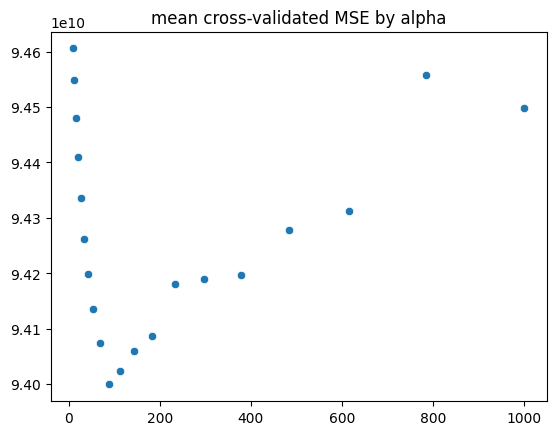

In [8]:
sns.scatterplot(x=model_mileage_age_lasso.alphas_, y=np.mean(model_mileage_age_lasso.mse_path_, axis=1))
plt.title('mean cross-validated MSE by alpha')
plt.show()

5. Plot the coefficient paths by $\alpha$.

In [9]:
coefs_for_alphas = []
for alpha in alphas:
    model = Lasso(alpha=alpha, random_state=343, max_iter=30000)
    model = model.fit(x_mileage_age_poly_scaled, y)
    coefs_for_alphas.append(model.coef_)
coefs_for_alphas = np.array(coefs_for_alphas)

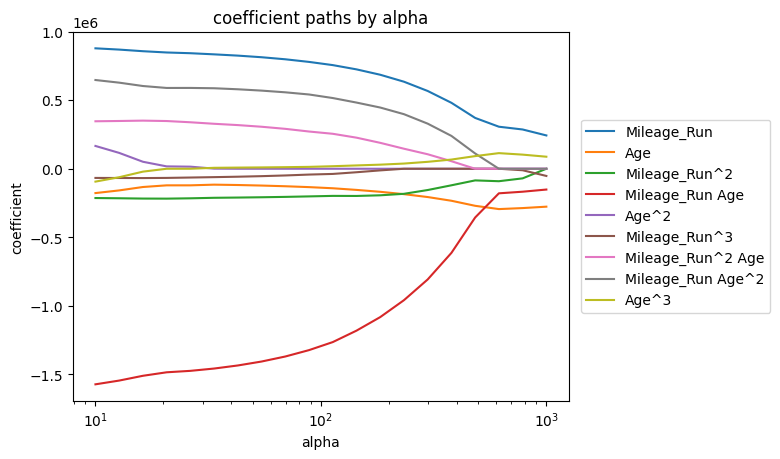

In [10]:
for i in range(coefs_for_alphas.shape[1]):
    plt.plot(alphas, coefs_for_alphas[:, i], label=poly_names[i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficient')
plt.title('coefficient paths by alpha')
plt.legend(loc='center right', bbox_to_anchor=(1.42, 0.5))
plt.show()

6. Which features are actually selected? What proportion are set equal to zero?

In [11]:
coefs_mileage_age_lasso = pd.DataFrame({'variable': poly_names, 'coef': model_mileage_age_lasso.coef_})
coefs_mileage_age_lasso

,variable,coef
0,Mileage_Run,7.790762e+05
1,Age,-1.339534e+05
2,Mileage_Run^2,-2.015634e+05
3,Mileage_Run Age,-1.322419e+06
4,Age^2,0.000000e+00
5,Mileage_Run^3,-4.240952e+04
6,Mileage_Run^2 Age,2.715062e+05
7,Mileage_Run Age^2,5.415432e+05
8,Age^3,1.374220e+04


In [12]:
print((1/9) * 100)

11.11111111111111


Most of the features are selected. The one variable that is dropped in the cross-validated model is `Age^2`, meaning $1/9$ or $11.1$% of the variables are set equal to zero.

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [13]:
coefs_comparison = coefs_mileage_age.set_index('variable')
coefs_comparison['lasso coef'] = coefs_mileage_age_lasso.set_index('variable')['coef']
coefs_comparison.columns = ['linear coef', 'lasso coef']
coefs_comparison['difference'] = coefs_comparison['lasso coef'] - coefs_comparison['linear coef']
coefs_comparison['magnitude difference'] = np.abs(coefs_comparison['lasso coef']) - np.abs(coefs_comparison['linear coef'])
coefs_comparison

,linear coef,lasso coef,difference,magnitude difference
variable,,,,
Mileage_Run,9.117748e+05,7.790762e+05,-132698.635572,-132698.635572
Age,-2.481722e+05,-1.339534e+05,114218.754278,-114218.754278
Mileage_Run^2,-2.072926e+05,-2.015634e+05,5729.219801,-5729.219801
Mileage_Run Age,-1.671212e+06,-1.322419e+06,348793.510111,-348793.510111
Age^2,3.505507e+05,0.000000e+00,-350550.719877,-350550.719877
Mileage_Run^3,-6.514490e+04,-4.240952e+04,22735.380191,-22735.380191
Mileage_Run^2 Age,3.388195e+05,2.715062e+05,-67313.266303,-67313.266303
Mileage_Run Age^2,7.167816e+05,5.415432e+05,-175238.392224,-175238.392224
Age^3,-2.100379e+05,1.374220e+04,223780.090816,-196295.684456


All of the coefficients decreased in magnitude from the linear model to the LASSO model (ie. the LASSO model had coefficients that were smaller in magnitude.) Only one of the coefficients changed sign — `Age^3`. 

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.

In [14]:
heart = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')
heart.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [15]:
x_heart_num = heart.loc[:, ['age', 'ejection_fraction', 'serum_creatinine']]
expander_num = PolynomialFeatures(degree=3, include_bias=False)
x_heart_num_poly = expander_num.fit_transform(x_heart_num)
x_heart_num_poly_names = expander_num.get_feature_names_out()

In [16]:
scaler = StandardScaler()
x_heart_num_poly_scaled = scaler.fit_transform(x_heart_num_poly)

In [17]:
x_heart_cat = heart.loc[:, ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
expander_cat = PolynomialFeatures(degree=3, include_bias=False, interaction_only=True)
x_heart_cat_poly = expander_cat.fit_transform(x_heart_cat)
x_heart_cat_poly_names = expander_cat.get_feature_names_out()

In [18]:
x_heart = pd.concat([pd.DataFrame(x_heart_num_poly_scaled), pd.DataFrame(x_heart_cat_poly)], axis=1)
heart_poly_names = list(x_heart_num_poly_names) + list(x_heart_cat_poly_names)

In [19]:
y = heart['DEATH_EVENT']

2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

In [20]:
model_heart = LinearRegression()
model_heart.fit(x_heart, y)

coefs_heart = pd.DataFrame({'variable': heart_poly_names, 'coef': model_heart.coef_})
coefs_heart

,variable,coef
0,age,1.549928
1,ejection_fraction,-2.025371
2,serum_creatinine,-0.739027
3,age^2,-3.547991
4,age ejection_fraction,-0.861860
5,age serum_creatinine,1.680570
6,ejection_fraction^2,3.317931
7,ejection_fraction serum_creatinine,2.604767
8,serum_creatinine^2,-2.703084
9,age^3,1.889040


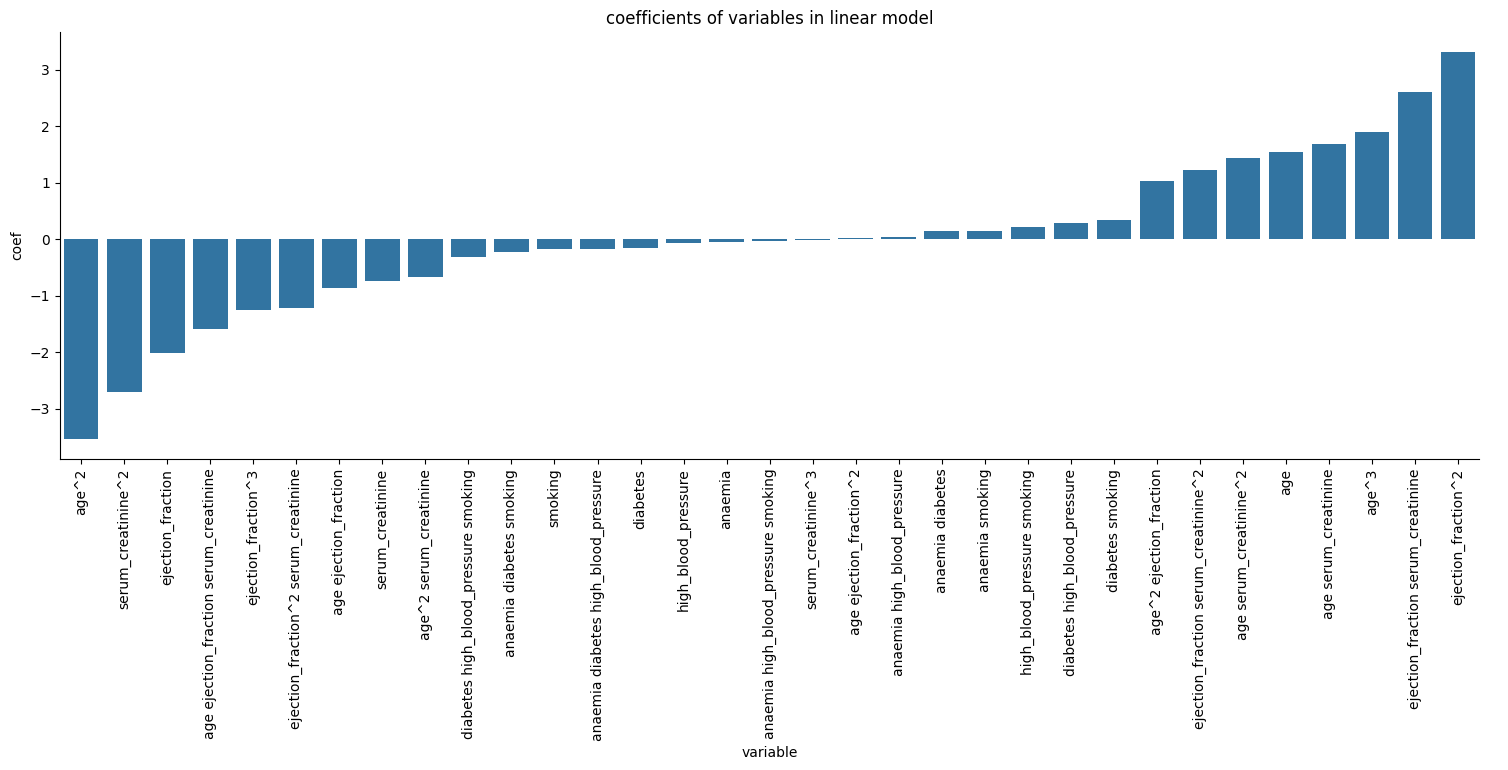

In [21]:
sns.catplot(coefs_heart.sort_values('coef'), kind='bar', x='variable', y='coef', aspect=3)
plt.title('coefficients of variables in linear model')
plt.xticks(rotation=90)
plt.show()

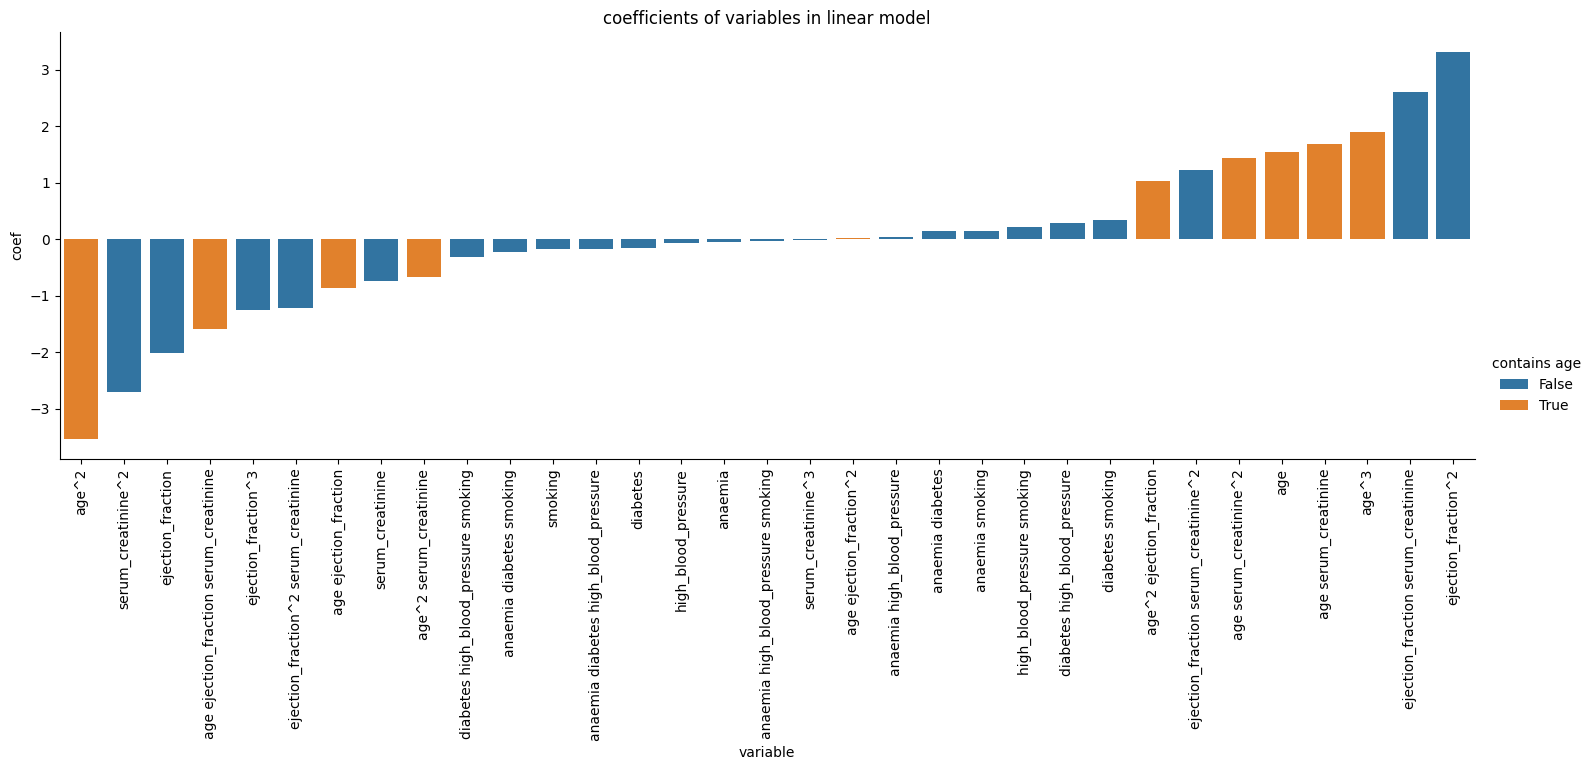

In [22]:
coefs_heart['contains age'] = ['age' in var for var in coefs_heart['variable']]
sns.catplot(coefs_heart.sort_values('coef'), kind='bar', x='variable', y='coef', hue='contains age', aspect=3)
plt.title('coefficients of variables in linear model')
plt.xticks(rotation=90)
plt.show()

`Age` having a positive coefficient is interesting since I would think that the likelihood of death increases as you get older. However, `Age^2` does have a negative coefficient and so do other variables that include `age`.

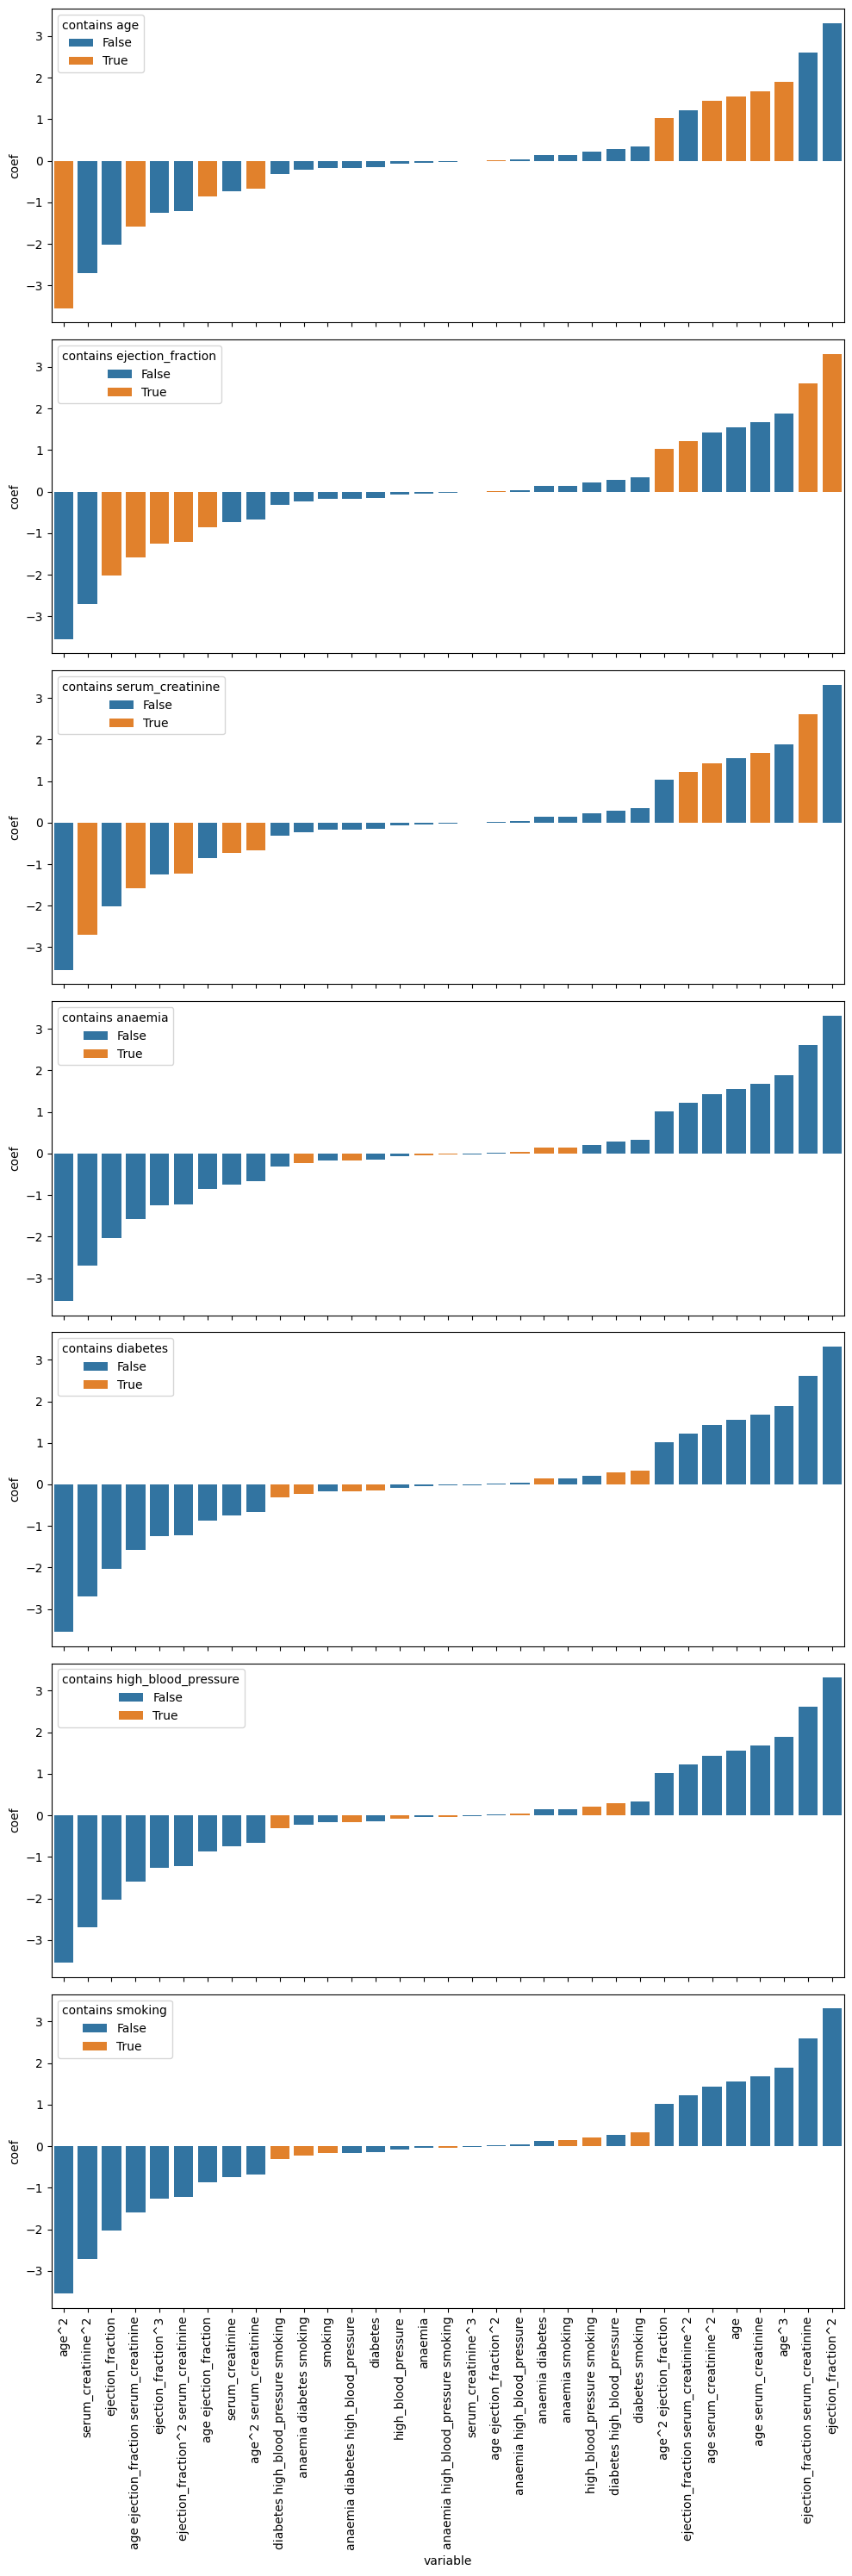

In [23]:
variables = ['age', 'ejection_fraction', 'serum_creatinine', 'anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
fig, axs = plt.subplots(7, 1, figsize=(10, 30), sharex=True, sharey=True)

for i in range(7):
    variable = variables[i]
    new_column = 'contains '+ variable

    coefs_heart[new_column] = [variable in var for var in coefs_heart['variable']]
    sns.barplot(coefs_heart.sort_values('coef'), x='variable', y='coef', hue=new_column, ax=axs[i])

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Overall, it kind of seems like the coefficient signs are all over the place. However, some of the interactions / higher-order powers do help resolve some contradictions.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)

In [24]:
alphas_heart = np.logspace(-5, 5, 30)
model_heart_lasso = LassoCV(cv=20, alphas=alphas_heart, random_state=343, max_iter=30000)
model_heart_lasso.fit(x_heart, y)

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.975e-02, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.070e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.536e+00, toleran

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([1.0000...00000000e+05])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",30000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",20
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


4. Plot the cross-validated MSE by $\alpha$.

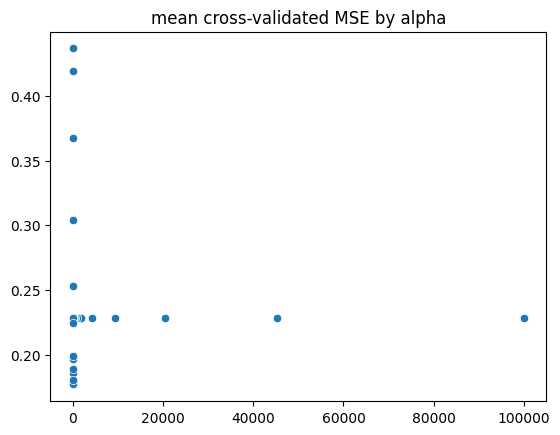

In [25]:
sns.scatterplot(x=model_heart_lasso.alphas_, y=np.mean(model_heart_lasso.mse_path_, axis=1))
plt.title('mean cross-validated MSE by alpha')
plt.show()

5. Plot the coefficient paths by $\alpha$.

In [26]:
coefs_for_alphas_heart = []
for alpha in alphas_heart:
    model = Lasso(alpha=alpha, random_state=343, max_iter=30000)
    model = model.fit(x_heart, y)
    coefs_for_alphas_heart.append(model.coef_)
coefs_for_alphas_heart = np.array(coefs_for_alphas_heart)

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.378e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.580e+00, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.330e+00, tolerance: 6.518e

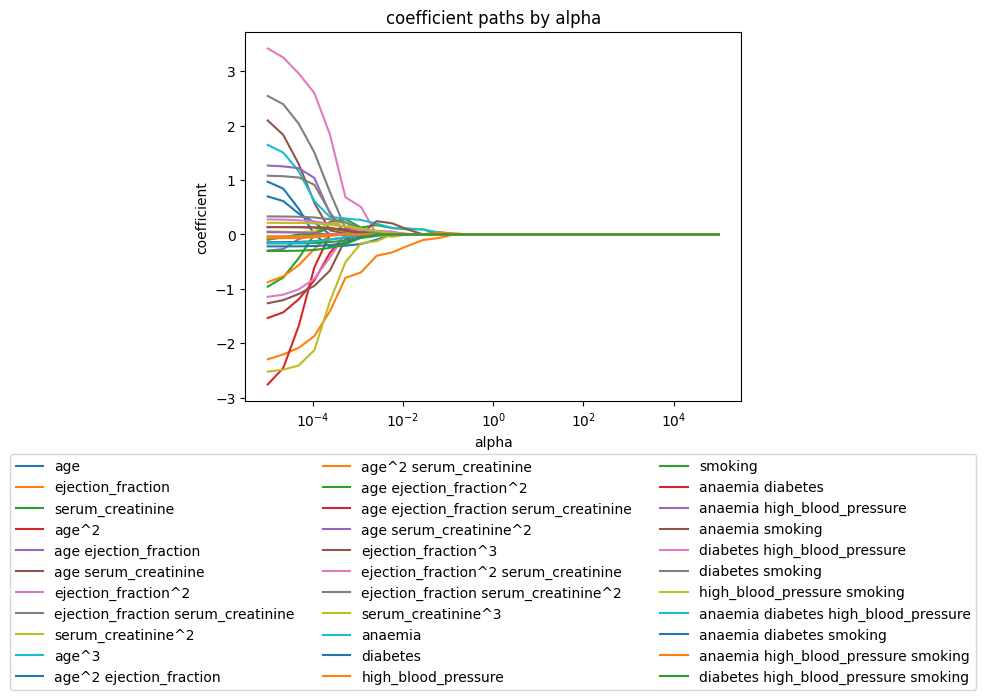

In [27]:
for i in range(coefs_for_alphas_heart.shape[1]):
    plt.plot(alphas_heart, coefs_for_alphas_heart[:, i], label=heart_poly_names[i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficient')
plt.title('coefficient paths by alpha')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.8), ncol=3)
plt.show()

6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [28]:
coefs_heart_lasso = pd.DataFrame({'variable': heart_poly_names, 'coef': model_heart_lasso.coef_})
coefs_heart_lasso

,variable,coef
0,age,-0.000000
1,ejection_fraction,-0.329656
2,serum_creatinine,0.116875
3,age^2,0.000000
4,age ejection_fraction,-0.000000
5,age serum_creatinine,0.000000
6,ejection_fraction^2,0.000000
7,ejection_fraction serum_creatinine,0.000000
8,serum_creatinine^2,-0.000000
9,age^3,0.117992


In [29]:
print('the features that are actually selected are', list(coefs_heart_lasso[coefs_heart_lasso['coef'] != 0]['variable']))

the features that are actually selected are ['ejection_fraction', 'serum_creatinine', 'age^3', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'serum_creatinine^3', 'anaemia', 'diabetes', 'high_blood_pressure', 'diabetes high_blood_pressure', 'diabetes smoking', 'high_blood_pressure smoking']


In [30]:
print(len(coefs_heart_lasso[coefs_heart_lasso['coef'] == 0]['variable']), 'out of', len(coefs_heart_lasso), 'variables have their coefficients set to zero, making up', ( len(coefs_heart_lasso[coefs_heart_lasso['coef'] == 0]['variable']) / len(coefs_heart_lasso) ) * 100, '%')

21 out of 33 variables have their coefficients set to zero, making up 63.63636363636363 %


In [31]:
heart_coefs_comparison = coefs_heart.set_index('variable')
heart_coefs_comparison['lasso coef'] = coefs_heart_lasso.set_index('variable')['coef']
heart_coefs_comparison = heart_coefs_comparison[['coef', 'lasso coef']]
heart_coefs_comparison.columns = ['linear coef', 'lasso coef']
heart_coefs_comparison['difference'] = heart_coefs_comparison['lasso coef'] - heart_coefs_comparison['linear coef']
heart_coefs_comparison['magnitude difference'] = np.abs(heart_coefs_comparison['lasso coef']) - np.abs(heart_coefs_comparison['linear coef'])
heart_coefs_comparison

,linear coef,lasso coef,difference,magnitude difference
variable,,,,
age,1.549928,-0.000000,-1.549928,-1.549928
ejection_fraction,-2.025371,-0.329656,1.695715,-1.695715
serum_creatinine,-0.739027,0.116875,0.855902,-0.622151
age^2,-3.547991,0.000000,3.547991,-3.547991
age ejection_fraction,-0.861860,-0.000000,0.861860,-0.861860
age serum_creatinine,1.680570,0.000000,-1.680570,-1.680570
ejection_fraction^2,3.317931,0.000000,-3.317931,-3.317931
ejection_fraction serum_creatinine,2.604767,0.000000,-2.604767,-2.604767
serum_creatinine^2,-2.703084,-0.000000,2.703084,-2.703084


All of the coefficients decrease in magnitude in the LASSO model compared to the linear model. Some of the coefficients do also change sign, for example, for `serum_creatinine` and `ejection_fraction^3`. The sign patterns make more sense for the LASSO model compared to the linear model. This is because the LASSO model is less complex by nature of including less variables. Thus, the variance goes down, but the bias goes up with the LASSO model. We might get worse predictions, but it is simpler than the linear model.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

![question 4 image](./regularization%20question%204.png)